In [1]:
suppressPackageStartupMessages(library(dplyr)) 
library(ggplot2)
library(pheatmap)
library(RColorBrewer)
library(Seurat)
library(harmony)
library(repr)

source("/projects/ps-renlab2/y2xie/scripts/basics.R")
source("/projects/ps-renlab2/y2xie/scripts/hicat_doubletfinder_mo.R")
source("/projects/ps-renlab2/y2xie/scripts/hicat_vg.R")
source("/projects/ps-renlab2/y2xie/scripts/DPT_help.R")

options(future.globals.maxSize = 64000 * 1024^2)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.2”
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Rcpp

Warning message:
“package ‘dichromat’ was built under R version 4.3.2”
Warning message:
“package ‘viridis’ was built under R version 4.3.2”
Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal




In [2]:
### Multiome kit barcode mapping
translate <- read.table("/projects/ps-renlab2/y2xie/ps-renlab/y2xie/projects/genome_ref/arc_bc-translation.txt", header = T, row.names = 1, sep = "\t")
translate$atac <- paste0(translate$atac, "-1")
translate$rna <- paste0(translate$rna, "-1")

In [3]:
### quick function
RunRNA2 <- function(obj, reduction = "pca", var = "none", batch.label = "none", k = 15) 
{
    if (var != "none") {
        obj <- SCTransform(obj, vars.to.regress = var, verbose = FALSE)
    }
    else {
        obj <- SCTransform(obj, verbose = FALSE)
    }
    obj <- RunPCA(obj, verbose = F)
    if (batch.label != "none") {
        obj <- RunHarmony(obj, group.by.vars = batch.label)
        reduction <- "harmony"
    }
    obj <- RunUMAP(obj, dims = 1:50, reduction = reduction, 
                   return.model = TRUE, seed.use = 921, metric = "cosine",
                   n.neighbors = k, min.dist = 0.1, n.components = 2L, umap.method = "uwot", 
                   uwot.sgd = TRUE, verbose = F)
    return(obj)
}

In [4]:
### set color
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

cellsubtype_colors <- c(
  NK = "#6A0DAD",                         
  T = "#9B59B6",                          
  Sinusoidal.Endothelial = "#CF1B14",     
  Lymphatic.Endothelial = "#FFCBC2",      
  Central.Vein.Endothelial = "#F27C78",   
  Vascular.Endothelial = "#8E0B0B",       
  Kupffer = "#B04202",                    
  Macrophage = "#F5AD75",                 
  Lipid.Associated.Macrophage = "#FF7105",
  B = "#9E239A",                          
  Plasma = "#E995E7",                     
  Cholangiocyte = "#E1AD01",              
  Quescent.HSC = "#4682B4",               
  Activated.HSC = "#1E90FF",              
  Mesenchymal = "#004F9E",                
  Mast = "#FD7BB8",                       
  Schwann = "#81CDC6",                    
  Hepatocytes.Zone1 = "#006D2C",          
  Hepatocytes.Zone2 = "#4DAF4A",          
  Hepatocytes.Zone3 = "#9ED69F",          
  Hepatocytes.Senescent = "#AED96A",      
  Hepatocytes.Stress = "#526E12"          
)

## Read in demuliplexing results

In [35]:
lmeta <- read.table('../scripts/liver_pool_metadata.xls', sep = "\t") %>% setNames(c("dna", "rna", "info"))
lmeta$info <- gsub("H3K27", "", lmeta$info)
lmeta$info <- gsub("-", "", lmeta$info)
lmeta$info <- gsub("[ _]", "\\.", lmeta$info)
tail(lmeta)

,dna,rna,info
,<chr>,<chr>,<chr>
9,QY_2592,QY_2593,Liver.pool4.ac1
10,QY_2594,QY_2595,Liver.pool4.ac2
11,QY_2596,QY_2597,Liver.pool4.me1
12,QY_2598,QY_2599,Liver.pool4.me2
13,LV003,QY_2556,Liver.pool1.ac
14,LV004,QY_2558,Liver.pool1.me3


In [74]:
demul_list <- list()
for (f in lmeta$info){
    dlib <- lmeta[lmeta$info == f,]$dna
    rlib <- lmeta[lmeta$info == f,]$rna
    demul_list[[f]] <- read.table(paste0("DPT.demux/", f, ".best"), header = T) %>% mutate(DNA_lib  = dlib, RNA_lib = rlib)
}

demul_list <- do.call(rbind, demul_list)
dim(demul_list)

### need to add RNA barcode to demul_list
demul_list$RBARCODE <- translate[match(demul_list$BARCODE, translate$atac), ]$rna
saveRDS(demul_list, "DPT.demux/all.rds")

[1] 270110     22

## Read in and merge all processed liver donor Droplet Paired-Tag object

In [4]:
library(foreach)
library(doParallel)
registerDoParallel(cores = 16)

Warning message:
“package ‘foreach’ was built under R version 4.3.2”
Warning message:
“package ‘doParallel’ was built under R version 4.3.2”
Loading required package: iterators

Warning message:
“package ‘iterators’ was built under R version 4.3.2”
Loading required package: parallel



In [76]:
### merge object: use matrix only to prevent memory crash when input number file / cell number is huge
### for FNIH metadata: also add in demul results
crna_list <- foreach(f = lmeta$rna, .packages = "Seurat") %dopar% {
    read_attempt <- try(readRDS(paste0("seurat_object/", f, ".rds")), silent = TRUE)
    if (inherits(read_attempt, "try-error")) {
        stop("Error reading ", f, "- skipping to next file.\n")
    }
    mmg <- readRDS(paste0("seurat_object/", f, ".rds"))
    tmp <- mmg@meta.data
    
    demul_list <- readRDS("DPT.demux/all.rds")
    demul_list <- demul_list[demul_list$RNA_lib == f, ]
    cvalid <- c("DROPLET.TYPE", "BEST.GUESS", "NEXT.GUESS")
    tmp[,cvalid] <- demul_list[match(rownames(tmp), demul_list$RBARCODE), cvalid]
    rownames(tmp) <- paste0(f, ":", rownames(tmp)) 
    
    mtx <- mmg[["RNA"]]@counts
    colnames(mtx) <- paste0(f, ":", colnames(mtx))
    return(list(mtx, tmp))
}

In [77]:
mtx_list <- lapply(crna_list, function(x) x[[1]])
meta_list <- lapply(crna_list, function(x) x[[2]])

### merge object
tmp <- Reduce(cbind, mtx_list[-1], mtx_list[[1]]) ### dont use do.call for cbind
tmeta <- do.call(rbind, meta_list)
mmg <- CreateSeuratObject(tmp, meta.data = tmeta)
mmg@meta.data[,c("rna", "rna_bc")] <- stringr::str_split_fixed(colnames(mmg), pattern = ":", n = 2)
mmg@meta.data[,c("dna", "library_info")] <- lmeta[match(mmg$rna, lmeta$rna), c("dna", "info")]

mmg
head(mmg)
gc()

An object of class Seurat 
36601 features across 262290 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,RNA_snn_res.0.3,seurat_clusters,doublet_score,doublet_ident,DROPLET.TYPE,BEST.GUESS,NEXT.GUESS,rna,rna_bc,dna,library_info
,<fct>,<dbl>,<int>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
QY_2577:AAACAGCCAACCTAAT-1,SeuratProject,16343,4797,0.006118828,0.3426543,4,4,0.3660,Doublet,DBL,"FNIH-Liver-HL160042-08012023,FNIH-Liver-HL211106-02262024,0.50","FNIH-Liver-HL211106-02262024,FNIH-Liver-HL160042-08012023,0.50",QY_2577,AAACAGCCAACCTAAT-1,QY_2576,Liver.pool2.ac1
QY_2577:AAACAGCCAACCTGGT-1,SeuratProject,12221,4193,0.008182636,0.3927665,3,3,0.0096,Singlet,SNG,"FNIH-Liver-HL160029-08012023,FNIH-Liver-HL160029-08012023,0.00","FNIH-Liver-HL160029-08012023,FNIH-Liver-HL210521-10252023,0.50",QY_2577,AAACAGCCAACCTGGT-1,QY_2576,Liver.pool2.ac1
QY_2577:AAACAGCCAAGCGATG-1,SeuratProject,9143,3637,0.032811987,0.4156185,9,9,0.4624,Doublet,DBL,"FNIH-Liver-HL210120-08012023,FNIH-Liver-HL160029-08012023,0.50","FNIH-Liver-HL160029-08012023,FNIH-Liver-HL210120-08012023,0.50",QY_2577,AAACAGCCAAGCGATG-1,QY_2576,Liver.pool2.ac1
QY_2577:AAACAGCCAAGCTAAA-1,SeuratProject,8051,3271,0.000000000,0.2980996,1,1,0.0000,Singlet,SNG,"FNIH-Liver-HL170060-08012023,FNIH-Liver-HL170060-08012023,0.00","FNIH-Liver-HL191025-08012023,FNIH-Liver-HL170060-08012023,0.50",QY_2577,AAACAGCCAAGCTAAA-1,QY_2576,Liver.pool2.ac1
QY_2577:AAACAGCCAAGGCCAA-1,SeuratProject,2173,1413,0.046019328,0.5062126,8,8,0.0010,Singlet,SNG,"FNIH-Liver-HL230316-08012023,FNIH-Liver-HL230316-08012023,0.00","FNIH-Liver-HL230316-08012023,FNIH-Liver-HL220825-08012023,0.50",QY_2577,AAACAGCCAAGGCCAA-1,QY_2576,Liver.pool2.ac1
QY_2577:AAACAGCCACAAAGAC-1,SeuratProject,5897,2563,0.033915550,0.1865355,4,4,0.0144,Singlet,SNG,"FNIH-Liver-HL190326-08012023,FNIH-Liver-HL190326-08012023,0.00","FNIH-Liver-HL190326-08012023,FNIH-Liver-HL221201-02262024,0.50",QY_2577,AAACAGCCACAAAGAC-1,QY_2576,Liver.pool2.ac1
QY_2577:AAACAGCCACTTAGGC-1,SeuratProject,6606,2901,0.000000000,0.4087193,2,2,0.0050,Singlet,SNG,"FNIH-Liver-HL200525-10252023,FNIH-Liver-HL200525-10252023,0.00","FNIH-Liver-HL200525-10252023,FNIH-Liver-HL170060-08012023,0.50",QY_2577,AAACAGCCACTTAGGC-1,QY_2576,Liver.pool2.ac1
QY_2577:AAACAGCCAGCTAACC-1,SeuratProject,5329,2636,0.093826234,0.6567836,8,8,0.0646,Singlet,DBL,"FNIH-Liver-HL160042-08012023,FNIH-Liver-HL170060-08012023,0.50","FNIH-Liver-HL170060-08012023,FNIH-Liver-HL160042-08012023,0.50",QY_2577,AAACAGCCAGCTAACC-1,QY_2576,Liver.pool2.ac1
QY_2577:AAACAGCCAGTCTATG-1,SeuratProject,4805,2492,0.166493236,0.6035380,7,7,0.0004,Singlet,SNG,"FNIH-Liver-HL200525-10252023,FNIH-Liver-HL200525-10252023,0.00","FNIH-Liver-HL200525-10252023,FNIH-Liver-HL191025-08012023,0.50",QY_2577,AAACAGCCAGTCTATG-1,QY_2576,Liver.pool2.ac1


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7238525,386.6,12587435,672.3,12587435,672.3
Vcells,3484941812,26588.0,8945455959,68248.5,7454288514,56871.8


## Quality filtering

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



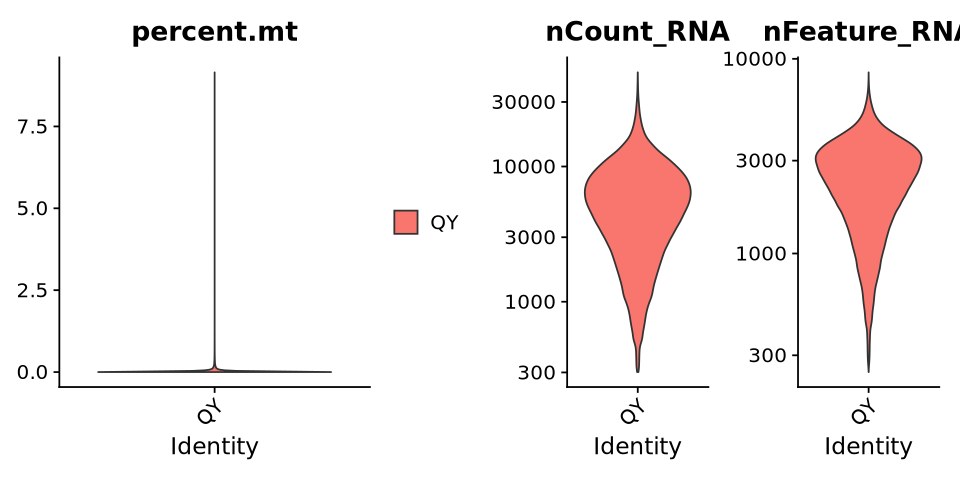

In [85]:
mmg <- subset(mmg, subset = DROPLET.TYPE == "SNG")

options(repr.plot.width = 8, repr.plot.height = 4)
t1 <- VlnPlot(mmg, "percent.mt", pt.size = 0)
t2 <- VlnPlot(mmg, c("nCount_RNA", "nFeature_RNA"), log = T, pt.size = 0)
cowplot::plot_grid(t1, t2)

In [86]:
ncol(mmg)

[1] 189121

Perform log CPM normalization...


Normalizing layer: counts

Warning message:
“No layers found matching search pattern provided”
Warning message:
“No layers found matching search pattern provided”
Warning message:
“Layer ‘scale.data’ is empty”
Warning message:
“Assay RNA changing from Assay5 to Assay”


Perform variable features selection using Brennecke's method...
number of variable genes calculated by hicat method: 2559
Perform data scaling and PCA...


Regressing out nCount_RNA

Centering and scaling data matrix



[1] "Downsample PC matrix to 50000 cells to calculate significant PC components"
Number of PC selected for downstream analysis: 40


Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9456050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9456050)”
Warning message:
“did not converge in 25 iterations”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony converged after 4 iterations



Number of neighbors selected for downstream analysis: 15
Perform UMAP embedding...


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


resolution used for leiden clustering: 0.3


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



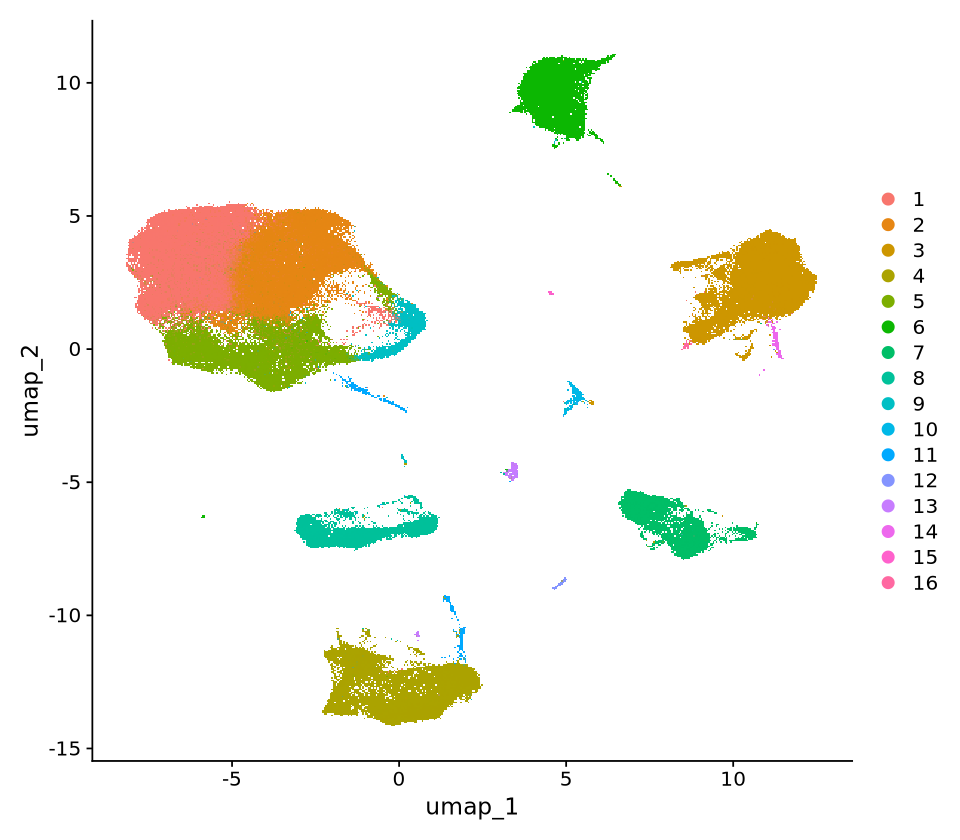

In [87]:
### correct batch effect based on donor pool instead of donors
### same as Gaulton lab
mmg <- seurat_onestep_clust(mmg, var = "nCount_RNA", batch.label = "library_info", res = 0.3)

options(repr.plot.width = 8, repr.plot.height = 7)
DimPlot(mmg)

In [88]:
qs::qsave(mmg, "FNIH_Liver_pool_DPT_SNG.qs", preset = "balanced", nthreads = 32)

## Run SoupX for each library individually

In [98]:
### use code described by WE
crna_list <- foreach(f = unique(mmg$rna), .packages = c("Seurat", "SoupX")) %dopar% {
    smmg <- subset(mmg, subset = rna == f)
    toc <- smmg[["RNA"]]@counts
    tod <- Read10X(paste0("../RNA/", f, "/outs/raw_feature_bc_matrix"))
    colnames(tod) <- paste0(f, ":", colnames(tod))
    sc <- SoupChannel(tod, toc)
    sc <- setDR(sc, as.data.frame(smmg@reductions$umap@cell.embeddings))
    sc <- setClusters(sc, smmg$seurat_clusters)
    sc <- autoEstCont(sc)
    out <- adjustCounts(sc, roundToInt=TRUE)
    background <- sc$soupProfile[order(sc$soupProfile$est,decreasing=TRUE),]
    background$sample <- f
    return(list(out, background))
}

In [ ]:
toc <- smmg[["RNA"]]@counts
tod <- Read10X(paste0("../RNA/", f, "/outs/raw_feature_bc_matrix"))
sc <- SoupChannel(tod, toc)
sc <- setDR(sc, as.data.frame(smmg@reductions$umap@cell.embeddings))
sc <- setClusters(sc, smmg$seurat_clusters)
sc <- autoEstCont(sc)
out <- adjustCounts(sc, roundToInt=TRUE)
background <- sc$soupProfile[order(sc$soupProfile$est,decreasing=TRUE),]
background$sample <- f
    return(list(out, background))
}

In [99]:
mtx_list <- lapply(crna_list, function(x) x[[1]])
bg <- do.call(rbind, lapply(crna_list, function(x) x[[2]]))
saveRDS(bg, "FNIH_Liver_pool_DPT_soupX_SNG.contam.rds")
                            
### merge object
tmp <- Reduce(cbind, mtx_list[-1], mtx_list[[1]]) ### dont use do.call for cbind
tmeta <- do.call(rbind, meta_list)
mmg2 <- CreateSeuratObject(tmp, meta.data = tmeta)
mmg2@meta.data <- mmg@meta.data[colnames(mmg2), ]

mmg2
gc()

An object of class Seurat 
36601 features across 189121 samples within 1 assay 
Active assay: RNA (36601 features, 0 variable features)
 1 layer present: counts

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7905327,422.2,202865104,10834.2,316976724,16928.4
Vcells,4139638235,31583.0,8945633737,68249.8,8945633737,68249.8


In [ ]:
### correct batch effect based on donor pool instead of single donor
### quick process with BICAN pipeline
mmg2 <- seurat_onestep_clust(mmg2, var = "nCount_RNA", batch.label = "library_info", res = 0.3)
gc()

Perform log CPM normalization...


Normalizing layer: counts

Warning message:
“No layers found matching search pattern provided”
Warning message:
“No layers found matching search pattern provided”
Warning message:
“Layer ‘scale.data’ is empty”
Warning message:
“Assay RNA changing from Assay5 to Assay”


Perform variable features selection using Brennecke's method...
number of variable genes calculated by hicat method: 2552
Perform data scaling and PCA...


Regressing out nCount_RNA

Centering and scaling data matrix



[1] "Downsample PC matrix to 50000 cells to calculate significant PC components"
Number of PC selected for downstream analysis: 50


Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9456050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9456050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9456050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9456050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9456050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 9456050)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations



In [ ]:
qs::qsave(mmg2, "FNIH_Liver_pool_DPT_SNG_SoupX.qs", preset = "balanced", nthreads = 32)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



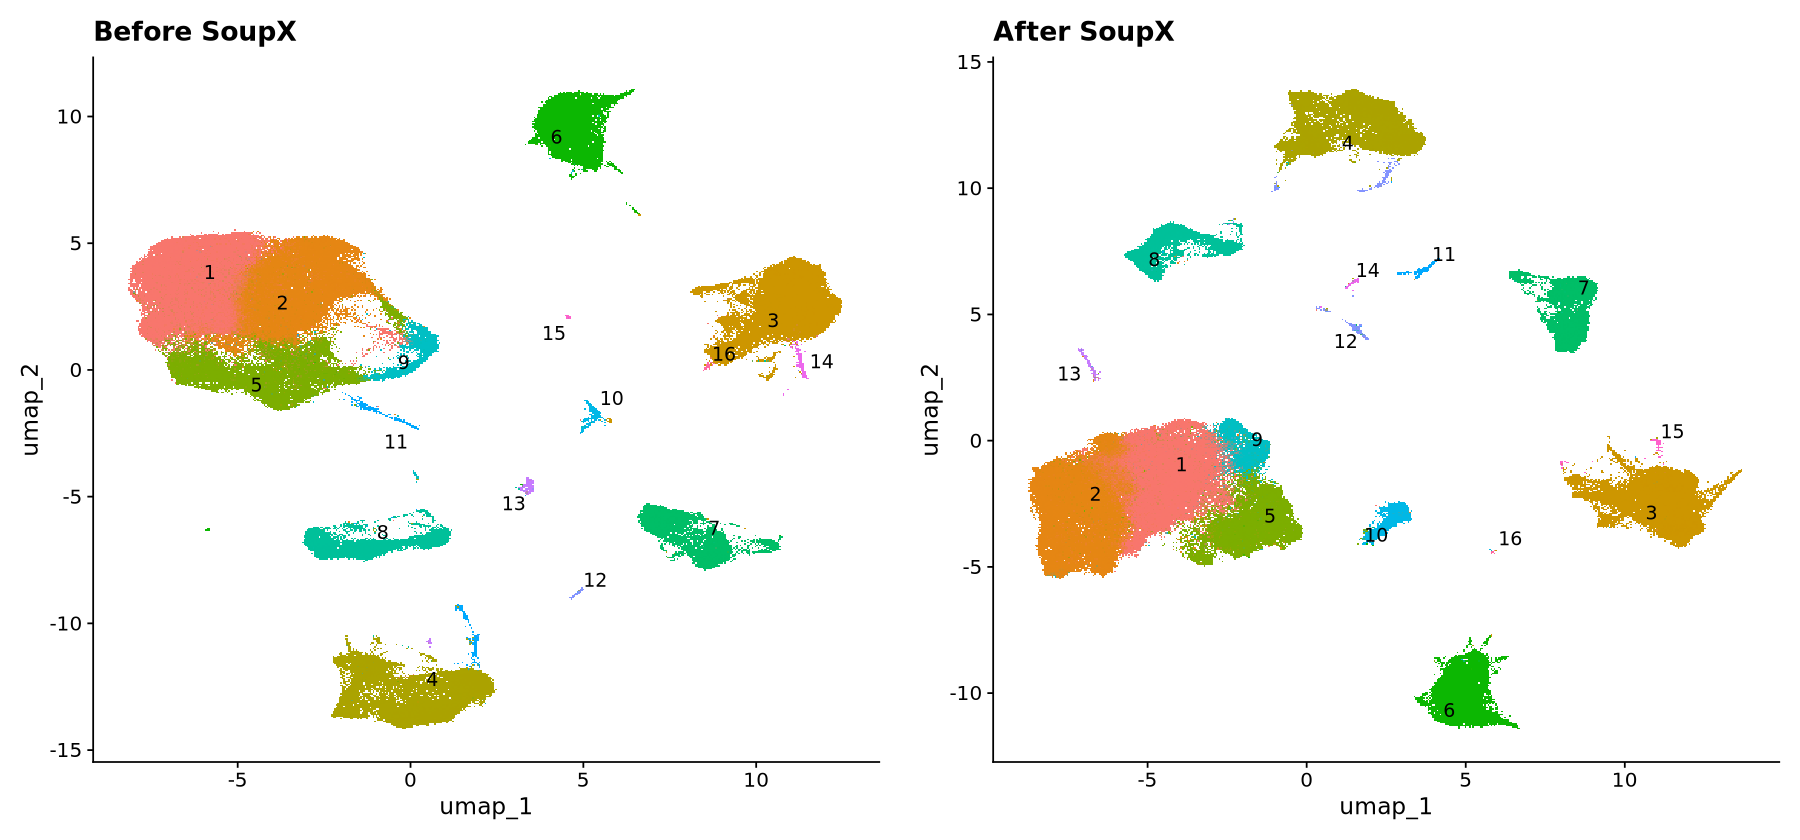

In [285]:
### Compare before and after soupX
options(repr.plot.width = 15, repr.plot.height = 7)
t1 <- DimPlot(mmg, label = T, repel = T) + ggtitle("Before SoupX") + NoLegend()
t2 <- DimPlot(mmg2, reduction = "umap", label = T, repel = T) + ggtitle("After SoupX") + NoLegend()

cowplot::plot_grid(t1, t2)